<a href="https://colab.research.google.com/github/D2718281828nis/AutomaticControlTheory-Denoising_Signals/blob/main/Extended-Kalman-Filter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This example vividly demonstrates that the Kalman filter is primarily designed to optimally estimate the system's state by reducing noise in its measurements (observations) and process noise (unmodeled disturbances affecting the state evolution). It does not filter noise present in the control input if that noisy input is what's explicitly provided to the filter as the control command.

The fundamental difference between the **Kalman Filter (KF)** and the **Extended Kalman Filter (EKF)** lies in their ability to handle system dynamics and measurement models:

1.  **Ordinary (Linear) Kalman Filter (KF):**
    *   **Assumption:** The standard Kalman Filter operates under the strict assumption that both the system's state transition function (how the state evolves over time) and the measurement function (how measurements relate to the state) are **linear**.
    *   **Equations:** It uses fixed system matrices (A, B, C, D) to describe these linear relationships.
    *   **Optimality:** If the system is truly linear and the noise is Gaussian, the KF provides the *optimal* estimate of the state.

2.  **Extended Kalman Filter (EKF):**
    *   **Purpose:** The EKF is an extension designed to handle **nonlinear** system dynamics and/or nonlinear measurement models.
    *   **How it Works (The 'Extension'):** Since the KF requires linear models, the EKF linearizes the nonlinear functions around the current state estimate at each time step. This linearization is done using **Jacobian matrices** (matrices of partial derivatives) of the nonlinear functions.
        *   **Prediction Step:** The nonlinear state transition function `f(x, u)` is linearized using its Jacobian `F`. This `F` matrix then replaces the `A` matrix of the standard KF.
        *   **Update Step:** Similarly, the nonlinear measurement function `h(x)` is linearized using its Jacobian `H`. This `H` matrix replaces the `C` matrix of the standard KF.
    *   **Non-Optimality:** Because the EKF performs a linearization, it's essentially an approximation. Therefore, unlike the standard KF, the EKF is generally **not optimal**, even for Gaussian noise. Its performance depends heavily on how nonlinear the system is and how good the linear approximation is at each step.

**In essence:**

*   The **ordinary Kalman Filter** is for **linear systems** where `x_k = A x_{k-1} + B u_k` and `z_k = C x_k`.
*   The **Extended Kalman Filter** is for **nonlinear systems** where `x_k = f(x_{k-1}, u_k)` and `z_k = h(x_k)`. It *extends* the linear KF by continuously approximating these nonlinear functions with linear ones (using Jacobians) at each step of the filtering process.

# Реализация расширенного фильтра Калмана (EKF)
*by Студент 3 курса РУДН Инженерной академии Габбасов Артур Азатович*



---


Я создал реализацию расширенного фильтра Калмана для примера с отслеживанием положения самолета с помощью радара, как описано в учебнике.

##Описание реализации

**Входные данные:**

1.   Измерения радара (наклонная дальность до самолета)
  *   Скалярные значения: наклонная дальность z от радара до самолёта
2.   Модель системы (нелинейные функции перехода состояния и измерений)
  *   Нелинейная функция перехода состояния
𝑓(𝑥,𝑢,𝑑𝑡)
(например, постоянная скорость, гравитация и т.п.)
  *     Нелинейная функция измерения
ℎ(𝑥) (наклонная дальность как функция от положения и высоты)
3.   Начальное состояние и ковариация
4.   Матрицы шумов процесса и измерений
  * Шум процесса 𝑄: неопределённость модели
  * Шум измерения 𝑅: погрешность радара
**Выходные данные:**

1.   Оценка состояния системы (горизонтальное положение и высота самолета)
2.   Матрица ковариации оценки состояния
  * 𝑃𝑘: отражает доверие к текущей оценке

**Ключевые особенности реализации:**

1.   Используется нелинейная модель для предсказания состояния `(f(x))` и измерений `(h(x))`
2.   На каждом шаге вычисляются якобианы этих функций для линеаризации
3.   Основные уравнения EKF реализованы в методах `predict()` и `update()`


---



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt, exp
import random

class ExtendedKalmanFilter:
    """
    Реализация расширенного фильтра Калмана (EKF) для нелинейных систем.
    """

    def __init__(self, dim_x, dim_z):
        """
        Инициализация EKF

        Параметры:
        dim_x - размерность вектора состояния
        dim_z - размерность вектора измерений
        """
        self.dim_x = dim_x
        self.dim_z = dim_z

        # Инициализация матриц
        self.x = np.zeros((dim_x, 1))      # Вектор состояния
        self.P = np.eye(dim_x)             # Матрица ковариации состояния
        self.Q = np.eye(dim_x)             # Матрица шума процесса
        self.R = np.eye(dim_z)             # Матрица шума измерений
        self.F = np.eye(dim_x)             # Матрица перехода состояния
        self.H = np.zeros((dim_z, dim_x))  # Матрица измерений

    def predict(self, f, F_jacobian, u=None, dt=None):
        """
        Этап предсказания EKF

        Параметры:
        f - нелинейная функция перехода состояния f(x, u, dt)
        F_jacobian - функция, возвращающая якобиан f(x, u, dt)
        u - вектор управления (опционально)
        dt - временной шаг (опционально)
        """
        # Предсказание состояния через нелинейную функцию
        self.x = f(self.x, u, dt)

        # Линеаризация - вычисление якобиана F
        self.F = F_jacobian(self.x, u, dt)

        # Предсказание ковариации
        self.P = self.F @ self.P @ self.F.T + self.Q

    def update(self, z, h, H_jacobian):
        """
        Этап обновления EKF

        Параметры:
        z - вектор измерений
        h - нелинейная функция измерений h(x)
        H_jacobian - функция, возвращающая якобиан h(x)
        """
        # Линеаризация - вычисление якобиана H
        self.H = H_jacobian(self.x)

        # Предсказание измерения
        z_pred = h(self.x)

        # Инновация (разница между измерением и предсказанием)
        y = z - z_pred

        # Ковариация инновации
        S = self.H @ self.P @ self.H.T + self.R

        # Оптимальная калмановская gain
        K = self.P @ self.H.T @ np.linalg.inv(S)

        # Обновление оценки состояния
        self.x = self.x + K @ y

        # Обновление ковариации
        I = np.eye(self.dim_x)
        self.P = (I - K @ self.H) @ self.P


In [6]:
    # Инициализация параметров
    dt = 0.1  # временной шаг
    t = np.arange(0, 100, dt)  # временная шкала

    # Истинная траектория самолета (горизонтальное положение и высота)
    true_pos = 1000 + 50*t  # линейное движение
    true_alt = 1000 + 10*np.sin(0.1*t)  # небольшие колебания высоты

    # Модель радара
    class Radar:
        def __init__(self):
            self.pos_noise = 10  # шум положения
            self.alt_noise = 5   # шум высоты

        def measure(self, pos, alt):
            # Измерение наклонной дальности с шумом
            slant = sqrt(pos**2 + alt**2)
            return slant + random.gauss(0, self.pos_noise)

    radar = Radar()

    # Инициализация EKF
    ekf = ExtendedKalmanFilter(dim_x=2, dim_z=1)

    # Начальное состояние: [горизонтальное положение, высота]
    ekf.x = np.array([[1000], [1000]])

    # Начальная ковариация
    ekf.P = np.diag([100, 100])

    # Шум процесса (предполагаем небольшие изменения)
    ekf.Q = np.diag([1, 0.1])

    # Шум измерений
    ekf.R = np.array([[radar.pos_noise**2]])

    # Функция перехода состояния (предполагаем постоянную скорость)
    def f(x, u, dt):
        # Простая модель: x_k+1 = x_k + v*dt
        # Для простоты предполагаем, что скорость постоянна
        # В реальности нужно оценивать и скорость
        return x

    # Якобиан функции перехода состояния
    def F_jacobian(x, u, dt):
        return np.eye(2)

    # Функция измерений (наклонная дальность)
    def h(x):
        pos = x[0, 0]
        alt = x[1, 0]
        return np.array([[sqrt(pos**2 + alt**2)]])

    # Якобиан функции измерений
    def H_jacobian(x):
        pos = x[0, 0]
        alt = x[1, 0]
        denom = sqrt(pos**2 + alt**2)
        return np.array([[pos/denom, alt/denom]])

    # Симуляция
    estimates = []
    measurements = []

    for i in range(len(t)):
        # Истинное состояние
        true_state = np.array([[true_pos[i]], [true_alt[i]]])

        # Измерение
        z = radar.measure(true_pos[i], true_alt[i])
        measurements.append(z)

        # Предсказание EKF
        ekf.predict(f, F_jacobian, dt=dt)

        # Обновление EKF
        ekf.update(np.array([[z]]), h, H_jacobian)

        # Сохранение оценки
        estimates.append(ekf.x.copy())

    # Визуализация результатов
    estimates = np.array(estimates).squeeze()
    measurements = np.array(measurements)


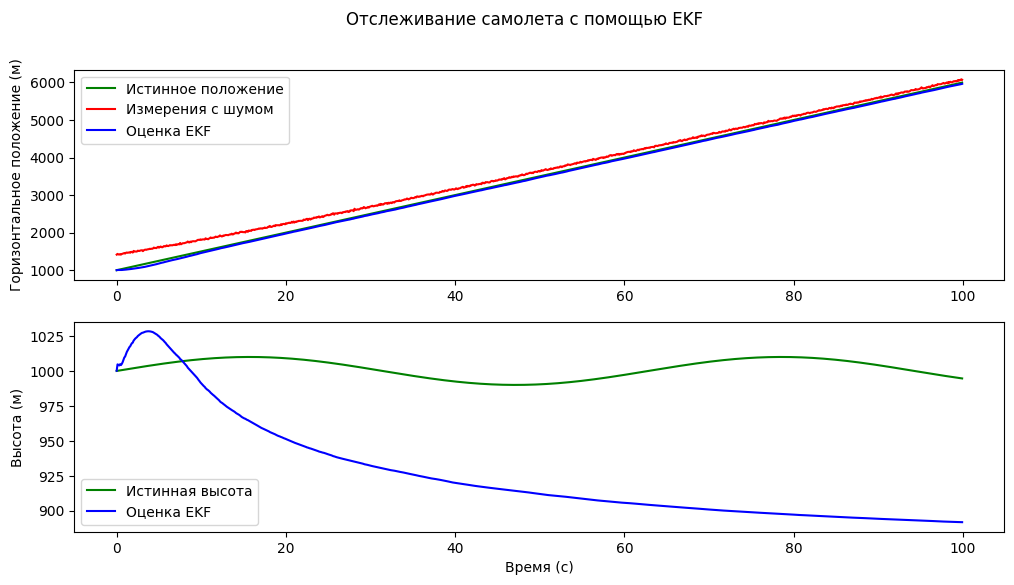

In [ ]:
    plt.figure(figsize=(12, 6))

    # График горизонтального положения
    plt.subplot(2, 1, 1)
    plt.plot(t, true_pos, 'g', label='Истинное положение')
    plt.plot(t, measurements, 'r', label='Измерения с шумом')
    plt.plot(t, estimates[:, 0], 'b', label='Оценка EKF')
    plt.ylabel('Горизонтальное положение (м)')
    plt.legend()

    # График высоты
    plt.subplot(2, 1, 2)
    plt.plot(t, true_alt, 'g', label='Истинная высота')
    plt.plot(t, estimates[:, 1], 'b', label='Оценка EKF')
    plt.ylabel('Высота (м)')
    plt.xlabel('Время (с)')
    plt.legend()

    plt.suptitle('Отслеживание самолета с помощью EKF')
    plt.show()

# Более сложный пример

In [7]:
!pip install control -q

In [11]:
K = 2
T = 5
dzeta = 0.1
W = control.tf(K, [T**2, 2*T*dzeta, 1])
print(W)

<TransferFunction>: sys[7]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

        2
  --------------
  25 s^2 + s + 1


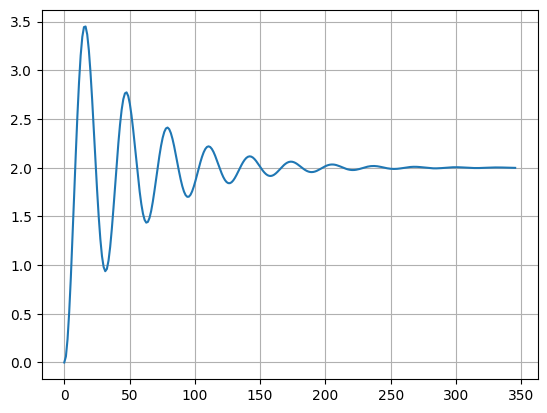

In [12]:
t, y = control.step_response(W)
plt.plot(t, y)
plt.grid()
plt.show()

Transfer Function W:
<TransferFunction>: sys[10]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

        2
  --------------
  25 s^2 + s + 1

Continuous-time State-Space Matrices:
A_c:
 [[-0.04 -0.04]
 [ 1.    0.  ]]
B_c:
 [[1.]
 [0.]]
C_c:
 [[0.   0.08]]
D_c:
 [[0.]]

Discrete-time State-Space Matrices (dt=0.1):
A_d:
 [[ 0.99580853 -0.00399174]
 [ 0.09979361  0.99980027]]
B_d:
 [[0.09979361]
 [0.00499317]]
C_d:
 [[0.   0.08]]
D_d:
 [[0.]]


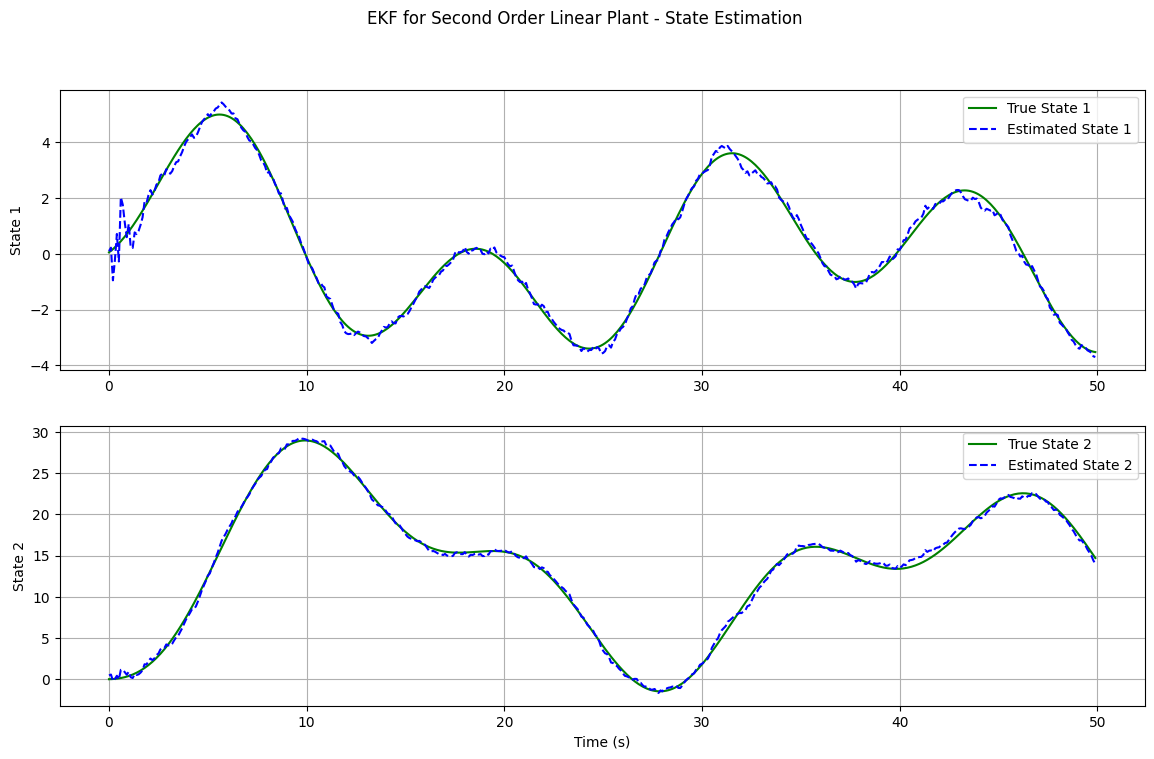

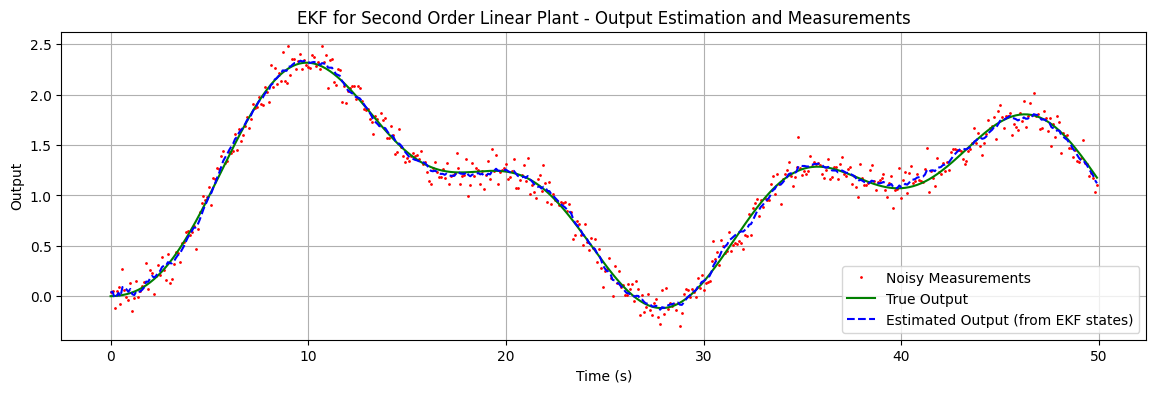

In [13]:
import control
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm # For discrete-time conversion manually if needed
import random # For noise

# Define the transfer function W from the previous cell
K = 2
T = 5
dzeta = 0.1
W = control.tf(K, [T**2, 2*T*dzeta, 1])
print("Transfer Function W:")
print(W)

# Convert to continuous-time state-space
sys_ss = control.ss(W)
A_c = sys_ss.A
B_c = sys_ss.B
C_c = sys_ss.C
D_c = sys_ss.D

print("\nContinuous-time State-Space Matrices:")
print("A_c:\n", A_c)
print("B_c:\n", B_c)
print("C_c:\n", C_c)
print("D_c:\n", D_c)

# Define time step for discretization and EKF
dt = 0.1 # Using the same dt as the original EKF example

# Discretize the continuous-time state-space model
sys_d = control.c2d(sys_ss, dt, method='zoh')
A_d = sys_d.A
B_d = sys_d.B
C_d = sys_d.C
D_d = sys_d.D

print("\nDiscrete-time State-Space Matrices (dt=0.1):")
print("A_d:\n", A_d)
print("B_d:\n", B_d)
print("C_d:\n", C_d)
print("D_d:\n", D_d)

# --- Extended Kalman Filter Setup for the State-Space Plant ---

# EKF parameters
dim_x = A_d.shape[0] # Number of states
dim_z = C_d.shape[0] # Number of measurements (outputs)

ekf_plant = ExtendedKalmanFilter(dim_x=dim_x, dim_z=dim_z)

# Initial state estimate (e.g., all zeros)
ekf_plant.x = np.zeros((dim_x, 1))

# Initial covariance
ekf_plant.P = np.eye(dim_x) * 10 # High initial uncertainty

# Process noise covariance (tune this)
# Assuming some small process noise for the linear model
ekf_plant.Q = np.eye(dim_x) * 0.01

# Measurement noise covariance (tune this)
measurement_noise_std = 0.1 # Example standard deviation
ekf_plant.R = np.array([[measurement_noise_std**2]])

# Functions for EKF (f, F_jacobian, h, H_jacobian)
# For a linear discrete-time system x_k+1 = Ad*x_k + Bd*u_k, y_k = Cd*x_k + Dd*u_k

def f_plant(x_k, u_k, dt_val):
    # State transition function: x_k+1 = Ad*x_k + Bd*u_k
    # u_k must be properly shaped for Bd @ u_k
    return A_d @ x_k + B_d @ u_k

def F_jacobian_plant(x_k, u_k, dt_val):
    # Jacobian of f_plant with respect to x_k is simply A_d for a linear system
    return A_d

def h_plant(x_k):
    # Measurement function: y_k = Cd*x_k + Dd*u_k
    # Assuming D_d is 0 for this transfer function, so y_k = Cd*x_k
    # The EKF update expects h(x_k) to return the predicted measurement given the state x_k
    return C_d @ x_k

def H_jacobian_plant(x_k):
    # Jacobian of h_plant with respect to x_k is simply C_d for a linear system
    return C_d

# --- Simulation ---
time_end = 50 # seconds
t = np.arange(0, time_end, dt)

# Input signal (e.g., a sinusoidal input)
input_signal = np.sin(0.5 * t) + 0.5 # Example input

# Store true states, estimated states, and noisy measurements
true_states = np.zeros((dim_x, len(t)))
estimated_states = np.zeros((dim_x, len(t)))
measurements = np.zeros((dim_z, len(t)))

# Initial true state (e.g., at equilibrium or 0)
current_true_state = np.zeros((dim_x, 1))

for i in range(len(t)):
    u_k = np.array([[input_signal[i]]]) # Current input

    # 1. Simulate the true plant (discrete-time state-space)
    # x_k+1 = Ad*x_k + Bd*u_k
    current_true_state = A_d @ current_true_state + B_d @ u_k
    true_states[:, i:i+1] = current_true_state

    # 2. Generate true measurement from the true state
    # y_k = Cd*x_k + Dd*u_k (D_d is zero here)
    true_measurement = C_d @ current_true_state

    # Add measurement noise
    noisy_measurement = true_measurement + np.random.randn(dim_z, 1) * measurement_noise_std
    measurements[:, i:i+1] = noisy_measurement

    # 3. EKF predict step
    ekf_plant.predict(f_plant, F_jacobian_plant, u=u_k, dt=dt)

    # 4. EKF update step
    ekf_plant.update(noisy_measurement, h_plant, H_jacobian_plant)

    # Store estimated state
    estimated_states[:, i:i+1] = ekf_plant.x

# --- Visualization ---
plt.figure(figsize=(14, 8))

# Plot states
for s in range(dim_x):
    plt.subplot(dim_x, 1, s + 1)
    plt.plot(t, true_states[s, :].flatten(), 'g-', label=f'True State {s+1}')
    plt.plot(t, estimated_states[s, :].flatten(), 'b--', label=f'Estimated State {s+1}')
    plt.ylabel(f'State {s+1}')
    plt.legend()
    plt.grid(True)

plt.xlabel('Time (s)')
plt.suptitle('EKF for Second Order Linear Plant - State Estimation')
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(t, measurements[0, :].flatten(), 'r.', markersize=2, label='Noisy Measurements')
plt.plot(t, (C_d @ true_states).flatten(), 'g-', label='True Output')
plt.plot(t, (C_d @ estimated_states).flatten(), 'b--', label='Estimated Output (from EKF states)')
plt.ylabel('Output')
plt.xlabel('Time (s)')
plt.title('EKF for Second Order Linear Plant - Output Estimation and Measurements')
plt.legend()
plt.grid(True)
plt.show()

### EKF Performance Comparison with Varying Measurement Noise (R)

Let's investigate how the Extended Kalman Filter's performance changes when the assumed measurement noise covariance `R` is varied. We'll run the simulation with different `measurement_noise_std` values and compare the estimated states and output against the true values and noisy measurements.


Running EKF with assumed measurement_noise_std = 0.1

Running EKF with assumed measurement_noise_std = 0.5

Running EKF with assumed measurement_noise_std = 2.0


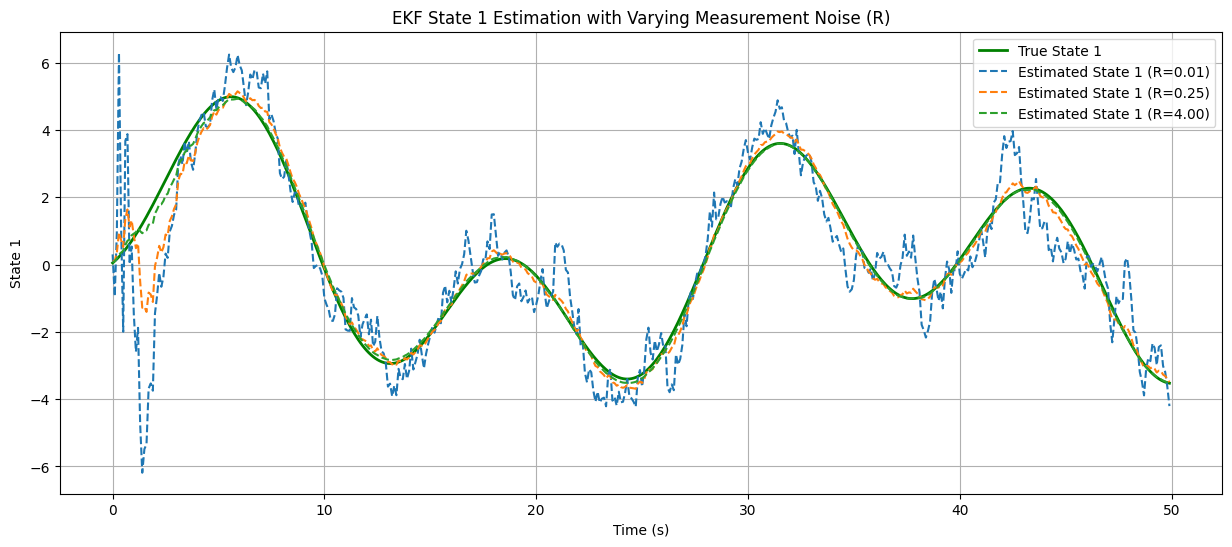

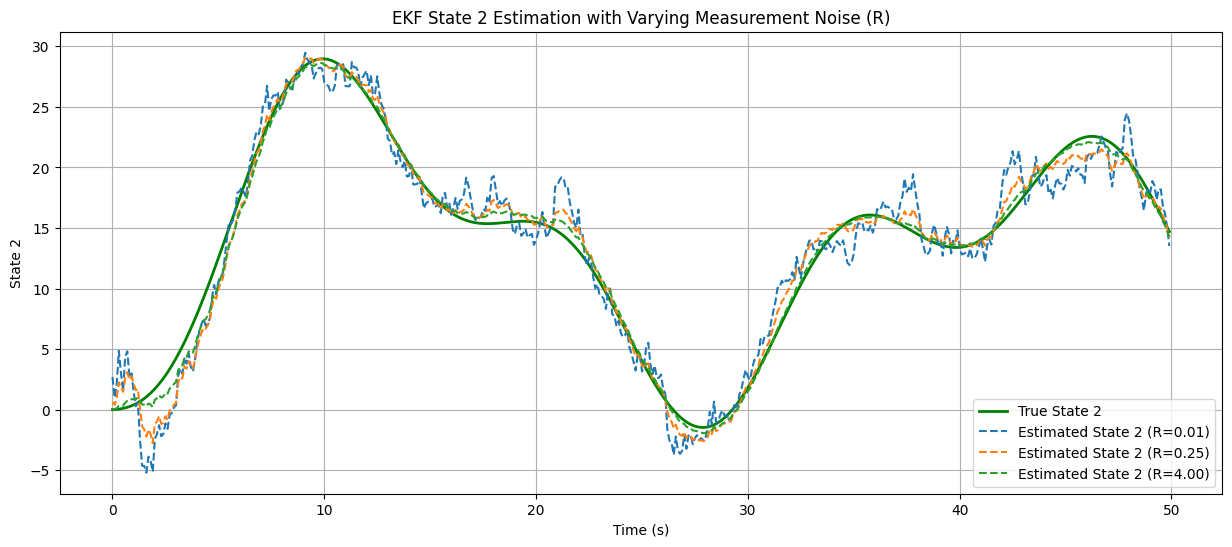

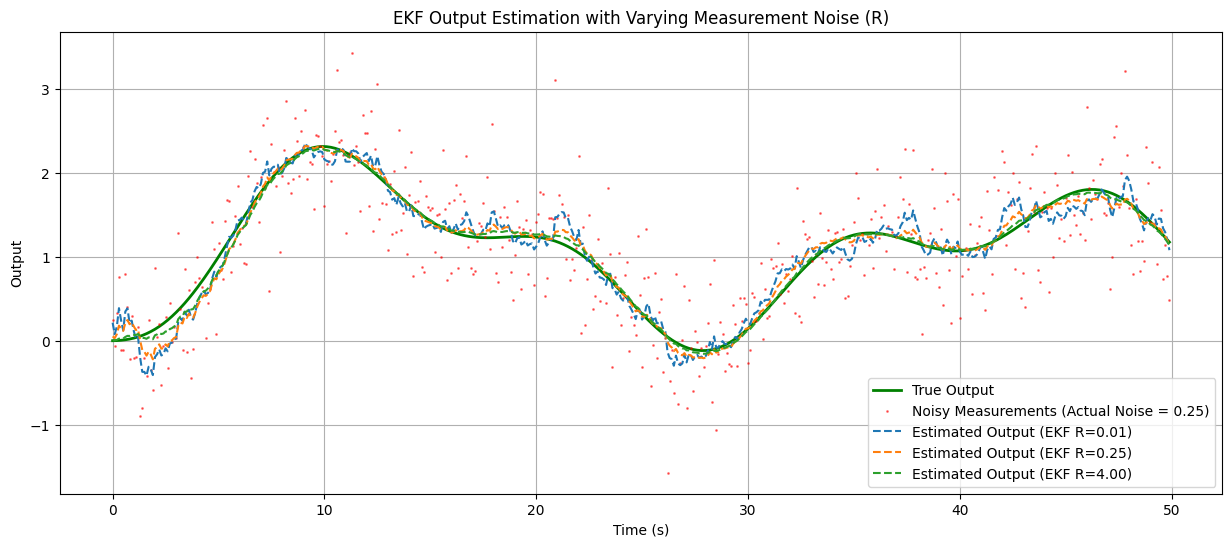

In [14]:
import control
import numpy as np
import matplotlib.pyplot as plt
import random

# Re-use the plant definition and discrete state-space matrices from the previous cell
K = 2
T = 5
dzeta = 0.1
W = control.tf(K, [T**2, 2*T*dzeta, 1])
sys_ss = control.ss(W)
dt = 0.1
sys_d = control.c2d(sys_ss, dt, method='zoh')
A_d = sys_d.A
B_d = sys_d.B
C_d = sys_d.C
D_d = sys_d.D

dim_x = A_d.shape[0] # Number of states
dim_z = C_d.shape[0] # Number of measurements (outputs)

# Define the EKF functions for this linear system (same as before)
def f_plant(x_k, u_k, dt_val):
    return A_d @ x_k + B_d @ u_k
def F_jacobian_plant(x_k, u_k, dt_val):
    return A_d
def h_plant(x_k):
    return C_d @ x_k
def H_jacobian_plant(x_k):
    return C_d

# --- Simulation Parameters ---
time_end = 50 # seconds
t = np.arange(0, time_end, dt)
input_signal = np.sin(0.5 * t) + 0.5 # Example input

# True plant simulation (run once to get true states and measurements)
true_states_overall = np.zeros((dim_x, len(t)))
measurements_overall = np.zeros((dim_z, len(t)))

# Use a fixed random seed for reproducibility of true measurements
np.random.seed(42)

current_true_state = np.zeros((dim_x, 1))
# Define the actual measurement noise for the plant simulation, independent of EKF's R
actual_measurement_noise_std = 0.5

for i in range(len(t)):
    u_k = np.array([[input_signal[i]]])
    current_true_state = A_d @ current_true_state + B_d @ u_k
    true_states_overall[:, i:i+1] = current_true_state
    true_measurement = C_d @ current_true_state
    noisy_measurement = true_measurement + np.random.randn(dim_z, 1) * actual_measurement_noise_std
    measurements_overall[:, i:i+1] = noisy_measurement

# --- Different Measurement Noise Covariance Levels for EKF ---
n_std_levels = [0.1, 0.5, 2.0] # Low, Medium (actual), High assumed noise
estimated_states_by_noise = {} # Dictionary to store estimates for each noise level
estimated_outputs_by_noise = {} # Dictionary to store estimated outputs

for noise_std in n_std_levels:
    print(f"\nRunning EKF with assumed measurement_noise_std = {noise_std}")
    ekf_compare = ExtendedKalmanFilter(dim_x=dim_x, dim_z=dim_z)
    ekf_compare.x = np.zeros((dim_x, 1)) # Initial state estimate
    ekf_compare.P = np.eye(dim_x) * 10    # Initial covariance
    ekf_compare.Q = np.eye(dim_x) * 0.01  # Process noise covariance (kept constant)
    ekf_compare.R = np.array([[noise_std**2]]) # Measurement noise covariance for EKF

    estimated_states_current = np.zeros((dim_x, len(t)))
    estimated_outputs_current = np.zeros((dim_z, len(t)))

    for i in range(len(t)):
        u_k = np.array([[input_signal[i]]])
        z_k = measurements_overall[:, i:i+1] # Use the same noisy measurements

        ekf_compare.predict(f_plant, F_jacobian_plant, u=u_k, dt=dt)
        ekf_compare.update(z_k, h_plant, H_jacobian_plant)
        estimated_states_current[:, i:i+1] = ekf_compare.x
        estimated_outputs_current[:, i:i+1] = C_d @ ekf_compare.x # Calculate output from estimated states

    estimated_states_by_noise[noise_std] = estimated_states_current
    estimated_outputs_by_noise[noise_std] = estimated_outputs_current

# --- Visualization for Comparison ---

# Plot State 1 Comparison
plt.figure(figsize=(15, 6))
plt.plot(t, true_states_overall[0, :].flatten(), 'g-', linewidth=2, label='True State 1')
for noise_std, est_states in estimated_states_by_noise.items():
    plt.plot(t, est_states[0, :].flatten(), '--', label=f'Estimated State 1 (R={noise_std**2:.2f})')
plt.ylabel('State 1')
plt.xlabel('Time (s)')
plt.title('EKF State 1 Estimation with Varying Measurement Noise (R)')
plt.legend()
plt.grid(True)
plt.show()

# Plot State 2 Comparison
plt.figure(figsize=(15, 6))
plt.plot(t, true_states_overall[1, :].flatten(), 'g-', linewidth=2, label='True State 2')
for noise_std, est_states in estimated_states_by_noise.items():
    plt.plot(t, est_states[1, :].flatten(), '--', label=f'Estimated State 2 (R={noise_std**2:.2f})')
plt.ylabel('State 2')
plt.xlabel('Time (s)')
plt.title('EKF State 2 Estimation with Varying Measurement Noise (R)')
plt.legend()
plt.grid(True)
plt.show()

# Plot Output Comparison
plt.figure(figsize=(15, 6))
plt.plot(t, (C_d @ true_states_overall).flatten(), 'g-', linewidth=2, label='True Output')
plt.plot(t, measurements_overall[0, :].flatten(), 'r.', markersize=2, alpha=0.5, label=f'Noisy Measurements (Actual Noise = {actual_measurement_noise_std**2:.2f})')
for noise_std, est_outputs in estimated_outputs_by_noise.items():
    plt.plot(t, est_outputs[0, :].flatten(), '--', label=f'Estimated Output (EKF R={noise_std**2:.2f})')
plt.ylabel('Output')
plt.xlabel('Time (s)')
plt.title('EKF Output Estimation with Varying Measurement Noise (R)')
plt.legend()
plt.grid(True)
plt.show()

# Пример с шумом

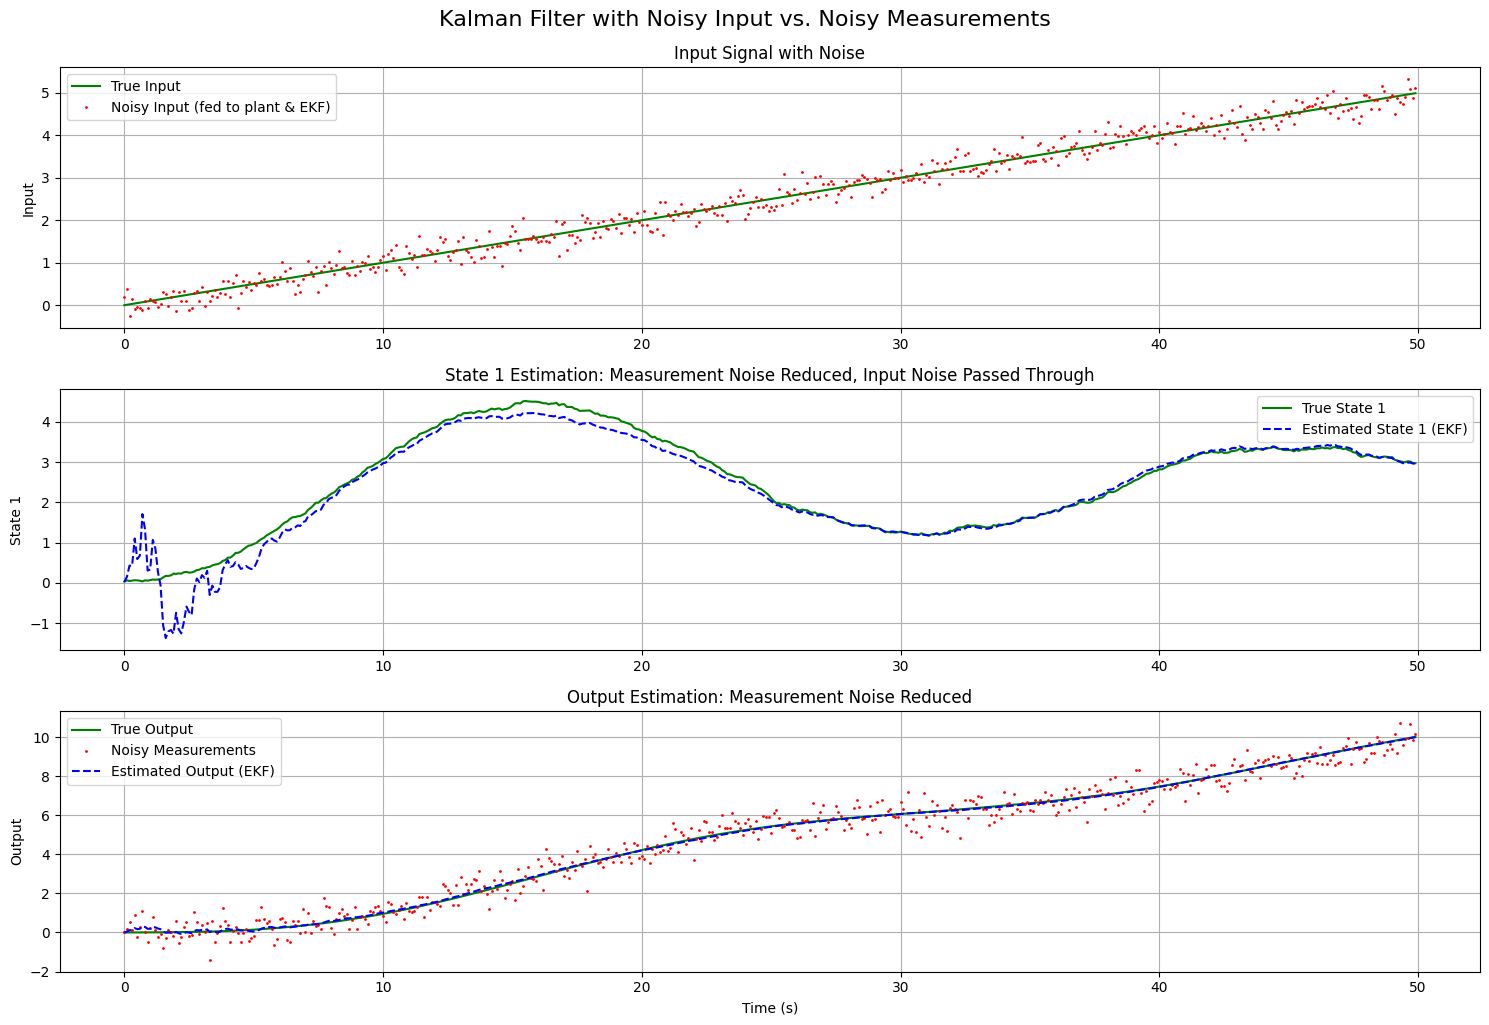

In [15]:
import control
import numpy as np
import matplotlib.pyplot as plt
import random

# Re-use the plant definition and discrete state-space matrices
# from the previous cell for consistency.
K = 2
T = 5
dzeta = 0.1
W = control.tf(K, [T**2, 2*T*dzeta, 1])
sys_ss = control.ss(W)
dt = 0.1
sys_d = control.c2d(sys_ss, dt, method='zoh')
A_d = sys_d.A
B_d = sys_d.B
C_d = sys_d.C
D_d = sys_d.D

dim_x = A_d.shape[0] # Number of states
dim_z = C_d.shape[0] # Number of measurements (outputs)

# Define the EKF functions for this linear system (same as before)
def f_plant(x_k, u_k, dt_val):
    # State transition function: x_k+1 = Ad*x_k + Bd*u_k
    return A_d @ x_k + B_d @ u_k

def F_jacobian_plant(x_k, u_k, dt_val):
    # Jacobian of f_plant with respect to x_k is simply A_d for a linear system
    return A_d

def h_plant(x_k):
    # Measurement function: y_k = Cd*x_k + Dd*u_k
    return C_d @ x_k

def H_jacobian_plant(x_k):
    # Jacobian of h_plant with respect to x_k is simply C_d for a linear system
    return C_d

# --- Simulation Parameters ---
time_end = 50 # seconds
t = np.arange(0, time_end, dt)

# True input signal (e.g., a ramp input)
true_input_signal = 0.1 * t # A slowly increasing input

# Add noise to the input signal - THIS IS THE 'INPUT NOISE'
input_noise_std = 0.2 # Standard deviation of noise added to input
noisy_input_signal = true_input_signal + np.random.randn(len(t)) * input_noise_std

# Measurement noise and process noise
measurement_noise_std = 0.5 # Standard deviation of noise in measurements
process_noise_std = 0.01    # Standard deviation of process noise

# Store true states, estimated states, and noisy measurements
true_states_input_noise_test = np.zeros((dim_x, len(t)))
estimated_states_input_noise_test = np.zeros((dim_x, len(t)))
measurements_input_noise_test = np.zeros((dim_z, len(t)))

# EKF Setup
ekf = ExtendedKalmanFilter(dim_x=dim_x, dim_z=dim_z)
ekf.x = np.zeros((dim_x, 1)) # Initial state estimate
ekf.P = np.eye(dim_x) * 10  # High initial uncertainty
ekf.Q = np.eye(dim_x) * (process_noise_std**2) # Process noise covariance
ekf.R = np.array([[measurement_noise_std**2]]) # Measurement noise covariance

# Initial true state (e.g., at equilibrium or 0)
current_true_state = np.zeros((dim_x, 1))

for i in range(len(t)):
    # The noisy input is treated as the 'known' control input for both the true plant and the EKF
    u_k_noisy = np.array([[noisy_input_signal[i]]])

    # 1. Simulate the true plant (with noisy input and process noise)
    current_true_state = A_d @ current_true_state + B_d @ u_k_noisy + np.random.randn(dim_x, 1) * process_noise_std
    true_states_input_noise_test[:, i:i+1] = current_true_state

    # 2. Generate true measurement from the true state, then add measurement noise
    true_measurement = C_d @ current_true_state
    noisy_measurement = true_measurement + np.random.randn(dim_z, 1) * measurement_noise_std
    measurements_input_noise_test[:, i:i+1] = noisy_measurement

    # 3. EKF predict step (uses the noisy input as u_k)
    ekf.predict(f_plant, F_jacobian_plant, u=u_k_noisy, dt=dt)

    # 4. EKF update step
    ekf.update(noisy_measurement, h_plant, H_jacobian_plant)

    # Store estimated state
    estimated_states_input_noise_test[:, i:i+1] = ekf.x

# --- Visualization ---
plt.figure(figsize=(15, 10))

# Plot Input Signal
plt.subplot(3, 1, 1)
plt.plot(t, true_input_signal, 'g-', label='True Input')
plt.plot(t, noisy_input_signal, 'r.', markersize=2, label='Noisy Input (fed to plant & EKF)')
plt.ylabel('Input')
plt.legend()
plt.grid(True)
plt.title('Input Signal with Noise')

# Plot Estimated State 1
plt.subplot(3, 1, 2)
plt.plot(t, true_states_input_noise_test[0, :].flatten(), 'g-', label='True State 1')
plt.plot(t, estimated_states_input_noise_test[0, :].flatten(), 'b--', label='Estimated State 1 (EKF)')
plt.ylabel('State 1')
plt.legend()
plt.grid(True)
plt.title('State 1 Estimation: Measurement Noise Reduced, Input Noise Passed Through')

# Plot Estimated Output and Measurements
plt.subplot(3, 1, 3)
plt.plot(t, (C_d @ true_states_input_noise_test).flatten(), 'g-', label='True Output')
plt.plot(t, measurements_input_noise_test[0, :].flatten(), 'r.', markersize=2, label='Noisy Measurements')
plt.plot(t, (C_d @ estimated_states_input_noise_test).flatten(), 'b--', label='Estimated Output (EKF)')
plt.ylabel('Output')
plt.xlabel('Time (s)')
plt.legend()
plt.grid(True)
plt.title('Output Estimation: Measurement Noise Reduced')

plt.tight_layout()
plt.suptitle('Kalman Filter with Noisy Input vs. Noisy Measurements', y=1.02, fontsize=16)
plt.show()